<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Bar Charts**


Estimated time needed: **30** minutes


In this lab, you will focus on visualizing data.

The dataset will be provided to you in the form of an RDBMS.

You will use SQL queries to extract the necessary data.


## Objectives


In this lab you will perform the following:


-   Visualize the distribution of data

-   Visualize the relationship between two features

-   Visualize the composition of data

-   Visualize comparison of data


## Setup: Working with the Database
**Install the needed libraries**


In [1]:
!pip install pandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 101.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 123.2 MB/s eta 0:00:00


In [2]:
!pip install matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 125.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 142.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 83.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.1/7.1 MB 89.1 MB/s eta 0:00:00


**Download and connect to the database file containing survey data.**


To start, download and load the dataset into a `pandas` DataFrame.



In [3]:
# Step 1: Download the dataset
!wget -O survey-data.csv https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv

# Step 2: Import necessary libraries and load the dataset
import pandas as pd
import matplotlib.pyplot as plt

# Load the data
df = pd.read_csv("survey-data.csv")

# Display the first few rows to understand the structure of the data
df.head()


--2026-06-20 09:09:31--  https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv
Resolving cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)... 169.63.118.104
Connecting to cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)|169.63.118.104|:443... connected.
200 OKequest sent, awaiting response... 
Length: 159525875 (152M) [text/csv]
Saving to: ‘survey-data.csv’

survey-data.csv     100%[===================>] 152.13M  35.7MB/s    in 4.3s    

2026-06-20 09:09:36 (35.1 MB/s) - ‘survey-data.csv’ saved [159525875/159525875]



,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
4,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN


### Task 1: Visualizing Data Distributions


##### 1. Histogram of `ConvertedCompYearly`


Visualize the distribution of yearly compensation (`ConvertedCompYearly`) using a histogram.



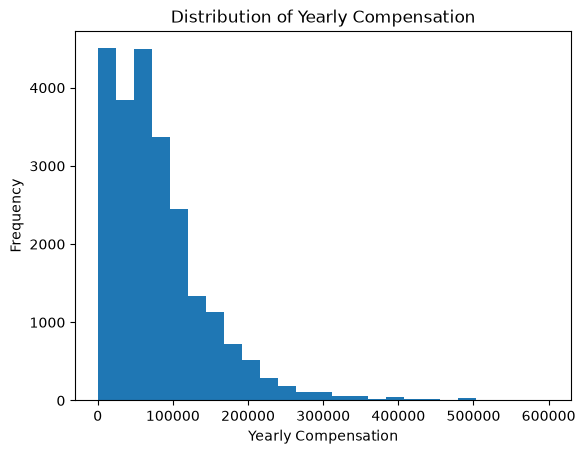

In [20]:
df_conv = df[["ConvertedCompYearly"]].copy()

df_conv["ConvertedCompYearly"] = pd.to_numeric(
    df_conv["ConvertedCompYearly"],
    errors="coerce"
)

# Remove extreme compensation values
df_conv = df_conv[
    (df_conv["ConvertedCompYearly"] > 0) &
    (df_conv["ConvertedCompYearly"] <= 600000)
]

df_conv = df_conv.dropna()

plt.hist(df_conv, bins=25)
plt.xlabel("Yearly Compensation")
plt.ylabel("Frequency")
plt.title("Distribution of Yearly Compensation")
plt.show()

##### 2. Box Plot of `Age`


Since `Age` is categorical in the dataset, convert it to numerical values for a box plot.



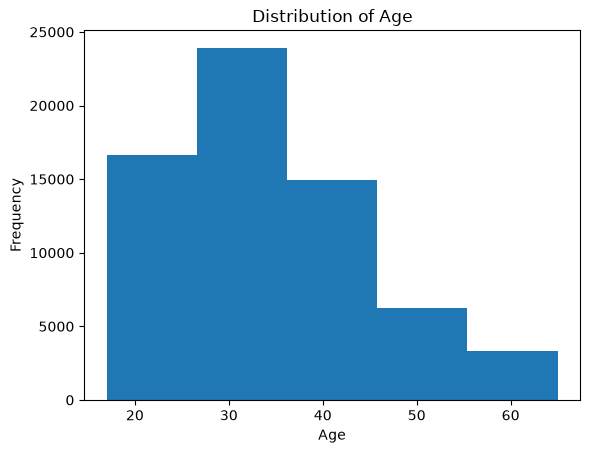

In [28]:
df_age = df[["Age"]].copy()

df_age["Age"] = df_age["Age"].astype("string").str.strip()

df_age = df_age.dropna()

age_map = {
    "Under 18 years old": 17,
    "18-24 years old": 21,
    "25-34 years old": 29.5,
    "35-44 years old": 39.5,
    "45-54 years old": 49.5,
    "55-64 years old": 59.5,
    "65 years or older": 65
}

df_age["AgeNumeric"] = df_age["Age"].map(age_map)

df_age = df_age["AgeNumeric"].dropna()

plt.hist(df_age, bins=5)
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.title("Distribution of Age")
plt.show()

### Task 2: Visualizing Relationships in Data


##### 1. Scatter Plot of `Age_numeric` and `ConvertedCompYearly`


Explore the relationship between age and compensation.



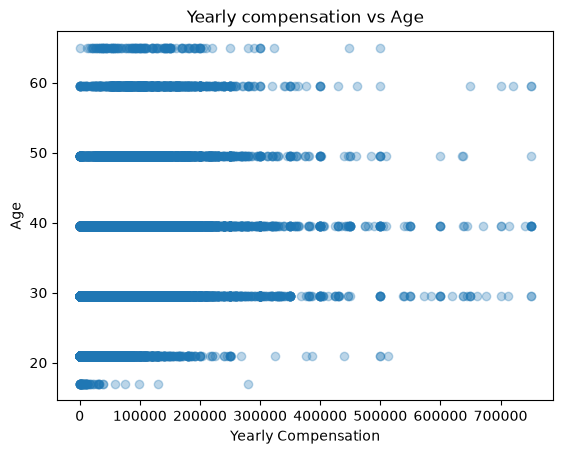

In [36]:
df_age_ccy = df[["Age", "ConvertedCompYearly"]].copy()

df_age_ccy["Age"] = df_age_ccy["Age"].astype("string").str.strip()

df_age_ccy["ConvertedCompYearly"] = pd.to_numeric(
    df_age_ccy["ConvertedCompYearly"],
    errors="coerce"
)

df_age_ccy = df_age_ccy.dropna(subset=["Age", "ConvertedCompYearly"])

# Remove extreme compensation values
df_age_ccy = df_age_ccy[
    (df_age_ccy["ConvertedCompYearly"] > 0) &
    (df_age_ccy["ConvertedCompYearly"] <= 750000)
]

age_map = {
    "Under 18 years old": 17,
    "18-24 years old": 21,
    "25-34 years old": 29.5,
    "35-44 years old": 39.5,
    "45-54 years old": 49.5,
    "55-64 years old": 59.5,
    "65 years or older": 65
}

df_age_ccy["AgeNumeric"] = df_age_ccy["Age"].map(age_map)

df_age_ccy = df_age_ccy.dropna(subset=["AgeNumeric"])

plt.scatter(
    df_age_ccy["ConvertedCompYearly"],
    df_age_ccy["AgeNumeric"],
    alpha=0.3
)

plt.xlabel("Yearly Compensation")
plt.ylabel("Age")
plt.title("Yearly compensation vs Age")


plt.show()

##### 2. Bubble Plot of `ConvertedCompYearly` and `JobSatPoints_6` with `Age_numeric` as Bubble Size


Explore how compensation and job satisfaction are related, with age as the bubble size.


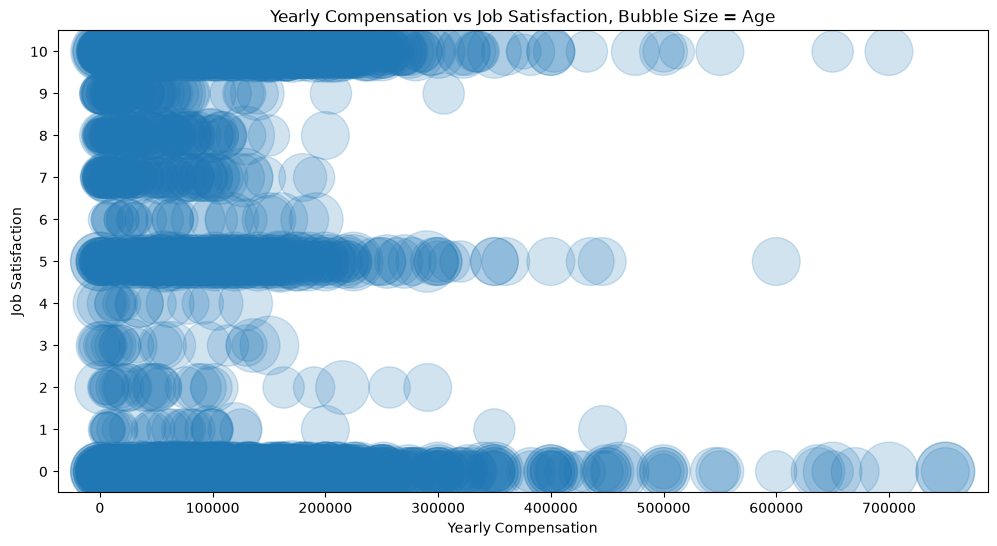

In [49]:
df_bubble = df[["ConvertedCompYearly", "JobSatPoints_6", "Age"]].copy()

#Clean columns
df_bubble["Age"] = df_bubble["Age"].astype("string").str.strip()

# Make sure the satisfaction columns are numeric
df_bubble["JobSatPoints_6"] = pd.to_numeric(
    df_bubble["JobSatPoints_6"],
    errors="coerce"
)

# Remove extreme compensation values
df_bubble = df_bubble[
    (df_bubble["ConvertedCompYearly"] > 0) &
    (df_bubble["ConvertedCompYearly"] <= 750000)
]

df_bubble = df_bubble.dropna(subset=["Age", "ConvertedCompYearly", "JobSatPoints_6"])


age_map = {
    "Under 18 years old": 17,
    "18-24 years old": 21,
    "25-34 years old": 29.5,
    "35-44 years old": 39.5,
    "45-54 years old": 49.5,
    "55-64 years old": 59.5,
    "65 years or older": 65
}

df_bubble["AgeNumeric"] = df_bubble["Age"].map(age_map)

df_bubble = df_bubble.dropna(subset=["AgeNumeric"])

plt.figure(figsize=(12, 6))

plt.scatter(
    df_bubble["ConvertedCompYearly"],
    df_bubble["JobSatPoints_6"],
    s=df_bubble["AgeNumeric"] * 30,
    alpha=0.2
)

plt.xlabel("Yearly Compensation")
plt.ylabel("Job Satisfaction")
plt.title("Yearly Compensation vs Job Satisfaction, Bubble Size = Age")

plt.yticks(range(0, 11))
plt.ylim(-0.5, 10.5)

plt.show()

### Task 3: Visualizing Composition of Data with Bar Charts


##### 1. Horizontal Bar Chart of `MainBranch` Distribution


Visualize the distribution of respondents’ primary roles to understand their professional focus.



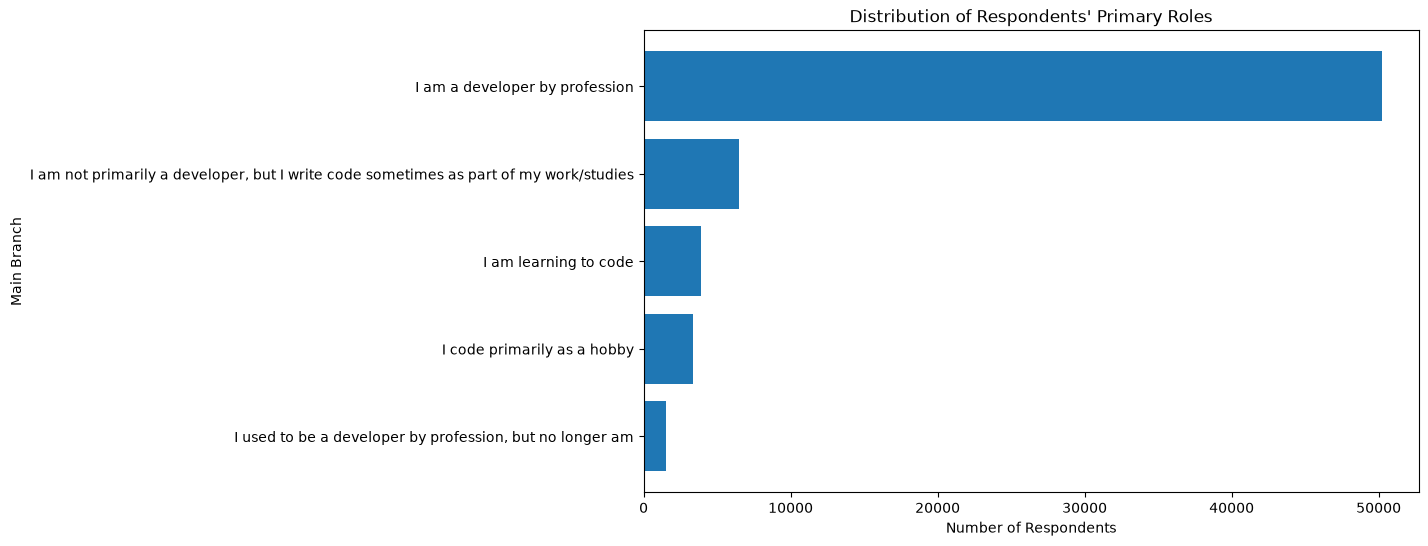

In [50]:
mainbranch_counts = df["MainBranch"].value_counts()

# Create horizontal bar chart
plt.figure(figsize=(10, 6))
plt.barh(mainbranch_counts.index, mainbranch_counts.values)

plt.xlabel("Number of Respondents")
plt.ylabel("Main Branch")
plt.title("Distribution of Respondents' Primary Roles")

# Put the largest bar at the top
plt.gca().invert_yaxis()

plt.show()

##### 2. Vertical Bar Chart of Top 5 Programming Languages Respondents Want to Work With


Identify the most desired programming languages based on `LanguageWantToWorkWith`.



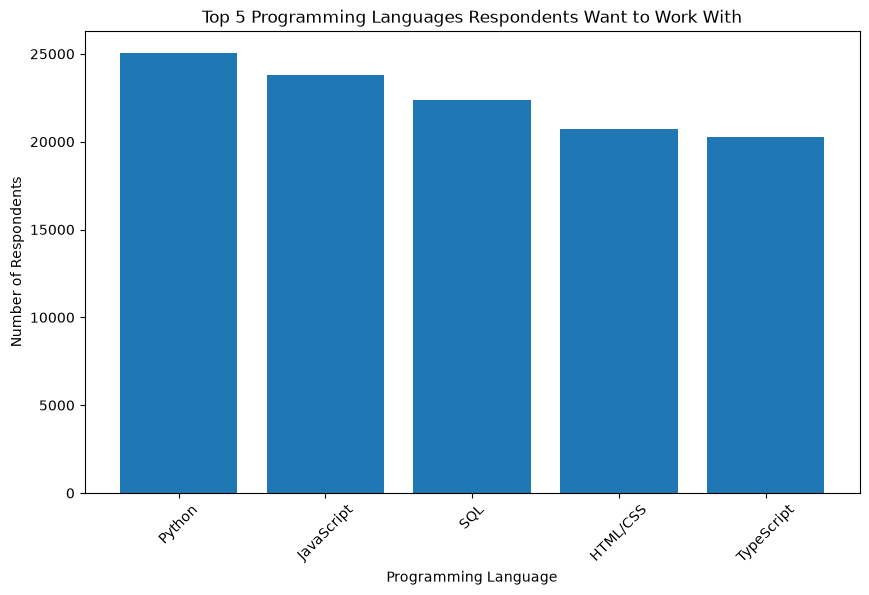

In [55]:
# Split multiple languages into separate rows
languages = df["LanguageWantToWorkWith"].dropna().str.split(";").explode()

# Count the top 5 languages
languages_counts = languages.value_counts().head(5)

# Create vertical bar chart
plt.figure(figsize=(10, 6))
plt.bar(languages_counts.index, languages_counts.values)

plt.xlabel("Programming Language")
plt.ylabel("Number of Respondents")
plt.title("Top 5 Programming Languages Respondents Want to Work With")

plt.xticks(rotation=45)

plt.show()

##### 3. Stacked Bar Chart of Median `JobSatPoints_6` and `JobSatPoints_7` by Age Group


Compare job satisfaction metrics across different age groups with a stacked bar chart.


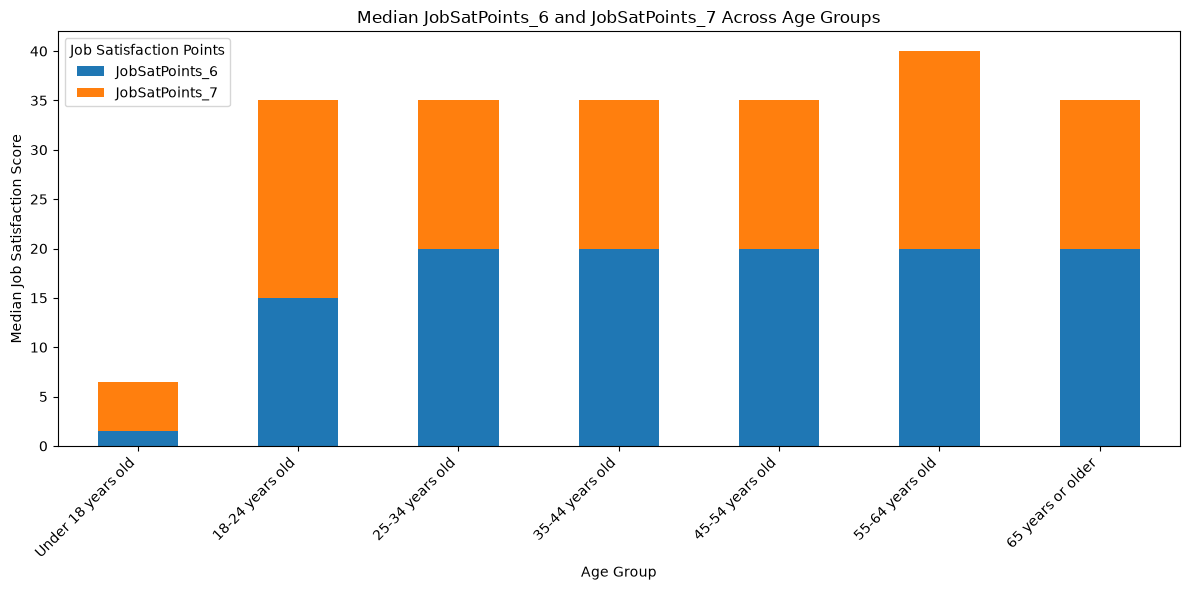

In [56]:
df_stack = df[["Age", "JobSatPoints_6", "JobSatPoints_7"]].copy()

# Clean Age column
df_stack["Age"] = df_stack["Age"].astype("string").str.strip()

# Make sure the satisfaction columns are numeric
df_stack["JobSatPoints_6"] = pd.to_numeric(
    df_stack["JobSatPoints_6"],
    errors="coerce"
)

df_stack["JobSatPoints_7"] = pd.to_numeric(
    df_stack["JobSatPoints_7"],
    errors="coerce"
)

# Age order
age_order = [
    "Under 18 years old",
    "18-24 years old",
    "25-34 years old",
    "35-44 years old",
    "45-54 years old",
    "55-64 years old",
    "65 years or older"
]

# Group by Age and calculate median
age_medians = (
    df_stack
    .groupby("Age")[["JobSatPoints_6", "JobSatPoints_7"]]
    .median()
    .reindex(age_order)
)

# Plot stacked bar chart
age_medians.plot(
    kind="bar",
    stacked=True,
    figsize=(12, 6)
)

plt.xlabel("Age Group")
plt.ylabel("Median Job Satisfaction Score")
plt.title("Median JobSatPoints_6 and JobSatPoints_7 Across Age Groups")

plt.xticks(rotation=45, ha="right")
plt.legend(title="Job Satisfaction Points")

plt.tight_layout()
plt.show()



##### 4. Bar Chart of Database Popularity (`DatabaseHaveWorkedWith`)


Identify the most commonly used databases among respondents by visualizing `DatabaseHaveWorkedWith`.



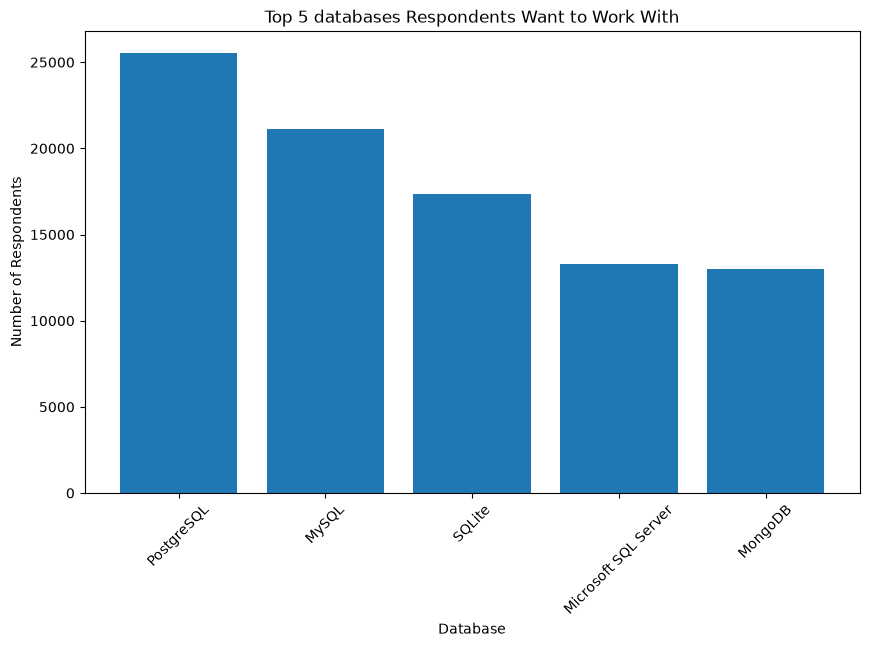

In [57]:
# Split multiple languages into separate rows
databases = df["DatabaseHaveWorkedWith"].dropna().str.split(";").explode()

# Count the top 5 languages
database_counts = databases.value_counts().head(5)

# Create vertical bar chart
plt.figure(figsize=(10, 6))
plt.bar(database_counts.index, database_counts.values)

plt.xlabel("Database")
plt.ylabel("Number of Respondents")
plt.title("Top 5 databases Respondents Want to Work With")

plt.xticks(rotation=45)

plt.show()

### Task 4: Visualizing Comparison of Data with Bar Charts


##### 1. Grouped Bar Chart of Median `ConvertedCompYearly` for Different Age Groups


Compare median compensation across multiple age groups with a grouped bar chart.



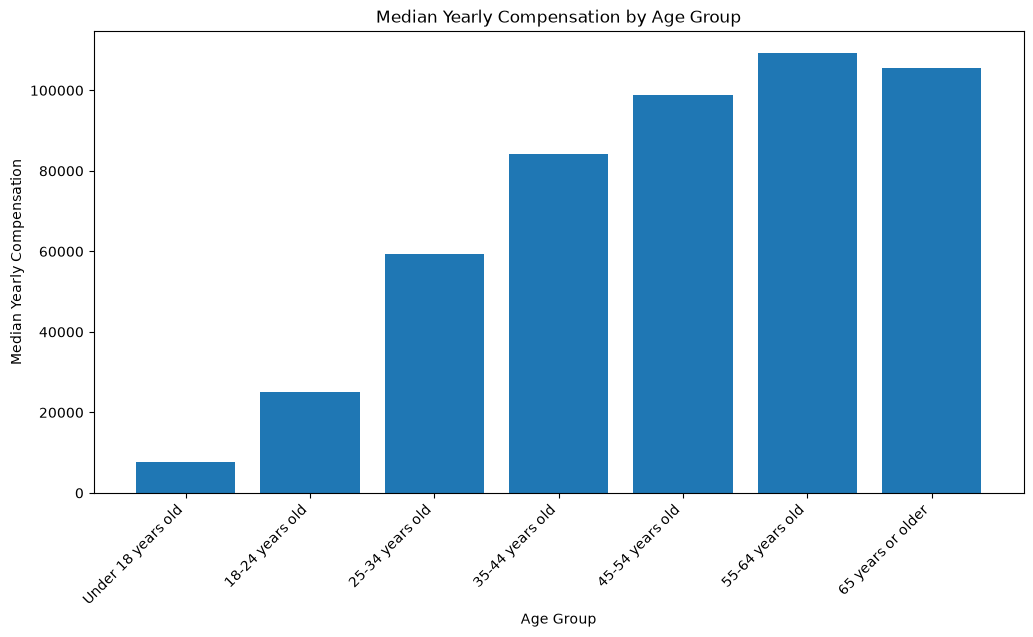

In [58]:
# Select needed columns
df_age_comp = df[["Age", "ConvertedCompYearly"]].copy()

# Convert compensation to numeric
df_age_comp["ConvertedCompYearly"] = pd.to_numeric(
    df_age_comp["ConvertedCompYearly"],
    errors="coerce"
)

# Remove missing values
df_age_comp = df_age_comp.dropna(subset=["Age", "ConvertedCompYearly"])

#Remove extreme compensation values
df_age_comp = df_age_comp[
    (df_age_comp["ConvertedCompYearly"] > 0) &
    (df_age_comp["ConvertedCompYearly"] <= 750000)
]

# Calculate median compensation by age group
median_comp_age = df_age_comp.groupby("Age")["ConvertedCompYearly"].median()

# Put age groups in sensible order
age_order = [
    "Under 18 years old",
    "18-24 years old",
    "25-34 years old",
    "35-44 years old",
    "45-54 years old",
    "55-64 years old",
    "65 years or older"
]

median_comp_age = median_comp_age.reindex(age_order)

# Plot bar chart
plt.figure(figsize=(12, 6))
plt.bar(median_comp_age.index, median_comp_age.values)

plt.xlabel("Age Group")
plt.ylabel("Median Yearly Compensation")
plt.title("Median Yearly Compensation by Age Group")

plt.xticks(rotation=45, ha="right")

plt.show()

##### 2. Bar Chart of Respondent Count by Country


Show the distribution of respondents by country to see which regions are most represented.



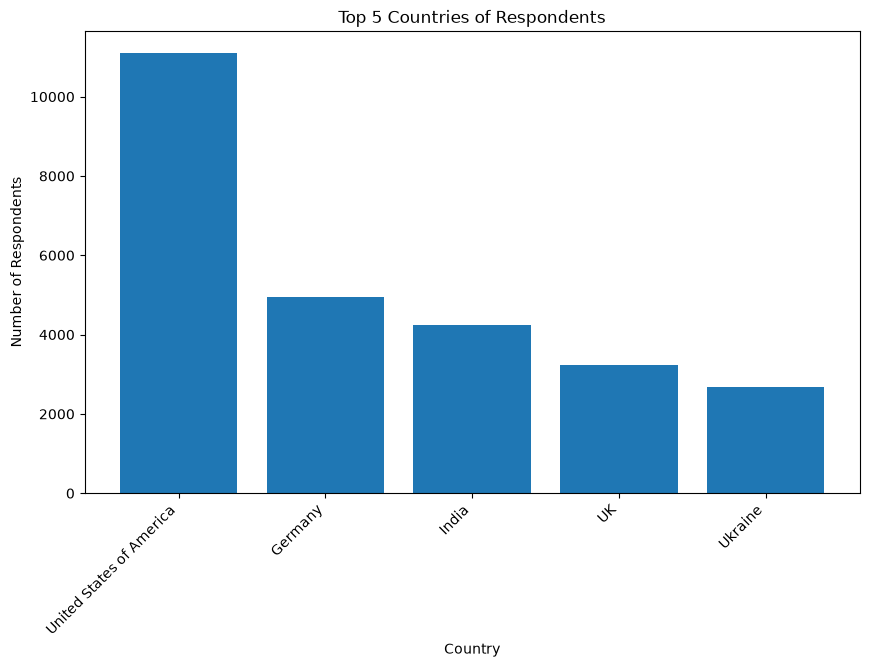

In [60]:
# Split multiple languages into separate rows
country = df["Country"].dropna().str.split(";").explode()

# Count the top 5 languages
country_counts = df["Country"].value_counts().head(5)

country_counts = country_counts.rename(index={
    "United Kingdom of Great Britain and Northern Ireland": "UK"
})

plt.figure(figsize=(10, 6))
plt.bar(country_counts.index, country_counts.values)

plt.xlabel("Country")
plt.ylabel("Number of Respondents")
plt.title("Top 5 Countries of Respondents")

plt.xticks(rotation=45, ha="right")
plt.show()

### Final Step: Review


This lab demonstrates how to create and interpret different types of bar charts, allowing you to analyze the composition, comparison, and distribution of categorical data in the Stack Overflow dataset, including main professional branches, programming language preferences, and compensation by age group. Bar charts effectively compare counts and median values across various categories.


## Summary


After completing this lab, you will be able to:
- Create a horizontal bar chart to visualize the distribution of respondents' primary roles, helping to understand their professional focus.
- Develop a vertical bar chart to identify the most desired programming languages based on the LanguageWantToWorkWith variable.
- Use a stacked bar chart to compare job satisfaction metrics across different age groups.
- Create a bar chart to visualize the most commonly used databases among respondents using the DatabaseHaveWorkedWith variable.


## Authors:
Ayushi Jain


### Other Contributors:
- Rav Ahuja
- Lakshmi Holla
- Malika


Copyright © IBM Corporation. All rights reserved.
